# Install package

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
# !nvidia-smi

In [24]:
!pip install mat4py
!pip show tensorflow
!pip install tensorflow
!pip show gym
!pip install gym
from google.colab import drive
drive.mount('/content/drive')
from scipy.io import loadmat
from scipy.io import savemat
import os
os.chdir('/content/drive/My Drive')

Name: tensorflow
Version: 2.20.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing_extensions, wrapt
Required-by: 
Name: gym
Version: 0.26.2
Summary: Gym: A universal API for reinforcement learning environments
Home-page: https://www.gymlibrary.dev/
Author: Gym Community
Author-email: jkterry@umd.edu
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: cloudpickle, gym_notices, numpy
Required-by: 
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
# 首先确保 TensorFlow 安装
try:
    import tensorflow as tf
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(e)

    # 或者限制 GPU 內存使用量
    if gpus:
        try:
            tf.config.experimental.set_memory_growth(gpus[0], True)
            # 或者設置內存限制
            # tf.config.experimental.set_virtual_device_configuration(
            #     gpus[0],
            #     [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=4096)])
        except RuntimeError as e:
            print(e)
    print(f"TensorFlow 版本: {tf.__version__}")
except ImportError:
    print("正在安装 TensorFlow...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])
    import tensorflow as tf
    print(f"TensorFlow 版本: {tf.__version__}")

# 其他导入
import collections
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import gym
import os
import random
import sys
from gym import spaces
from gym.utils import seeding
import copy
from mat4py import loadmat
import time

# TensorFlow 相关导入
from tensorflow import keras
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.layers import RNN
import tensorflow.keras.backend as K

# 设置 numpy 打印选项
np.set_printoptions(precision=16)

print("所有导入成功完成！")

TensorFlow 版本: 2.20.0
所有导入成功完成！


# Environment Setup

In [26]:
# Transient Frequency Control Porblem Environment
class Transient_Frequency(gym.Env):
    def  __init__(self,M,E,Pm,D,D_reactance,delta_t,omega_max,omega_min,dim_omega,dim_lambda,Penalty_action):
        self.param_gamma=1
        self.M=M
        self.E=E
        self.Pm=Pm
        self.D=D
        self.D_reactance=D_reactance
        self.delta_t=delta_t
        self.omega_max=omega_max
        self.omega_min=omega_min
        self.dim_omega=dim_omega
        self.dim_lambda=dim_lambda
        self.Penalty_action=Penalty_action
        self.viewer = None
        self.state=[]

        self.state_transfer1=np.vstack((np.hstack((np.identity((dim_lambda)),np.zeros((dim_lambda,dim_omega)))),\
          np.hstack((delta_t*np.transpose(D),np.identity((dim_omega))-delta_t*np.diag(np.squeeze(E/M))))))

        self.state_transfer2=np.hstack((np.zeros((dim_omega,dim_lambda)),np.identity((dim_omega))))

        self.state_transfer3=np.hstack((np.zeros((dim_omega,dim_lambda)),delta_t*(np.diag(np.squeeze((M**(-1)))))))

        self.select_add_omega=np.vstack((np.zeros((dim_lambda,1)),np.ones((dim_omega,1))))

        self.select_omega=np.vstack((np.zeros((dim_lambda,dim_omega)),np.identity(dim_omega)))

        self.select_lambda=np.vstack((np.identity(dim_lambda),np.zeros((dim_omega,dim_lambda))))

    def step(self,action,Pm):
        self.state=copy.deepcopy(self.state@self.state_transfer1 \
                -((delta_t*((np.sin(self.state@self.select_lambda))@D_reactance)@D)*(M**(-1)))@self.state_transfer2 \
                    + (Pm+action)@self.state_transfer3)

        loss = self.param_gamma*pow(self.state,2)@self.select_add_omega
        return self.state, loss

    def set_state(self, state_input):
        self.state=state_input

In [27]:
# Simulation data load from IEEE 39-bus system
data = loadmat('/content/drive/MyDrive/Colab Notebooks/RL_for_Optimal_Frequency_Control/data/IEEE-39-adjacency-matrix.mat')
D=data['D']
D=np.asarray(D)

data = loadmat('/content/drive/MyDrive/Colab Notebooks/RL_for_Optimal_Frequency_Control/data/IEEE-39-power-initial-balanced.mat')
Power_initial=data['power_initial']
Power_initial=np.asarray(Power_initial)

data = loadmat('/content/drive/MyDrive/Colab Notebooks/RL_for_Optimal_Frequency_Control/data/IEEE-39-rotational-inertial-generator.mat')
Rotational_inertial_generator=data['rotational_inertial_generator']
Rotational_inertial_generator=np.asarray(Rotational_inertial_generator)

data = loadmat('/content/drive/MyDrive/Colab Notebooks/RL_for_Optimal_Frequency_Control/data/IEEE-39-rotational-inertial-load.mat')
Rotational_inertial_load=data['rotational_inertial_load']
Rotational_inertial_load=np.asarray(Rotational_inertial_load)

data = loadmat('/content/drive/MyDrive/Colab Notebooks/RL_for_Optimal_Frequency_Control/data/IEEE-39-susceptance-matrix.mat')
D_reactance=data['D_reactance']
D_reactance=np.asarray(D_reactance)

In [28]:
dim_omega=39 #dimension of action space
dim_lambda=46 #dimension of lambda
dim_state=dim_omega+dim_lambda #dimension of state space
action_units=dim_omega
delta_t=0.0008
M=((np.vstack((Rotational_inertial_load,Rotational_inertial_generator)))[:,1]).reshape(1,dim_omega)
E=1*np.ones((1,dim_omega),dtype=np.float32)
L=np.transpose(D)@(D_reactance)@D
Laplacian=np.transpose(D)@D
A_nom=-Laplacian+np.diag(np.diag(Laplacian))
syn_frequence=np.sum(Power_initial,axis=0)/np.sum(E,axis=1)
f_initial=D@np.linalg.pinv(L)@(Power_initial-syn_frequence*np.transpose(E))
Pm=np.transpose(Power_initial)
Pm_nominal=copy.deepcopy(Pm)
omega_max=0.2
omega_min=-0.2
#Penalty_action=40
Penalty_action=40*200
equilibrium_init=np.hstack((np.transpose(f_initial),syn_frequence*np.ones((1,dim_omega))))
env = Transient_Frequency(M,E,Pm,D,D_reactance,delta_t,omega_max,omega_min,dim_omega,dim_lambda,Penalty_action)

# Init Simulation

In [29]:
#Controller in Zhang & Cortes (2019)
def Action_Yifu(state,env):
    states_controlled=state@env.select_omega
    alpha_plus = 2*(states_controlled-omega_max*np.ones((dim_omega,)))
    alpha_minus = 2*(omega_min*np.ones((dim_omega,))-states_controlled)
    q_xp = E*states_controlled+(np.sin(state@env.select_lambda)@D_reactance)@D-Pm
    omega_th_max=(0.5*omega_max*np.ones((dim_omega,)))
    omega_th_min=(0.5*omega_min*np.ones((dim_omega,)))
    def getBinaryNumpy(imgNumpy, boundary=0):
        one = np.ones_like(imgNumpy)
        zero = np.zeros_like(imgNumpy)
        return np.where(imgNumpy>boundary, one, zero)
    nonlinear_plus = getBinaryNumpy(states_controlled-omega_th_max, boundary=0)*\
      np.minimum(np.zeros(dim_omega,), -alpha_plus*((states_controlled-omega_th_max)**(-1))+q_xp)
    nonlinear_minus = getBinaryNumpy(omega_th_min-state@env.select_omega, boundary=0)*\
      np.maximum(np.zeros(dim_omega,), alpha_minus*((omega_th_min-states_controlled)**(-1))+q_xp)

    action = nonlinear_plus + nonlinear_minus
    return action

<>:84: SyntaxWarning: invalid escape sequence '\o'
<>:94: SyntaxWarning: invalid escape sequence '\l'
<>:84: SyntaxWarning: invalid escape sequence '\o'
<>:94: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-731651751.py:84: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('$\omega$ (rad/s)', fontsize=14)
/tmp/ipython-input-731651751.py:94: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\lambda$ (rad)', fontsize=14)


array([[-5.4973581437217235e-02,  3.2707308774645200e-02,
         5.9656008656650134e-02, -2.3515390129794492e-02,
        -4.6755964202806262e-02,  2.4253774999692793e-02,
        -5.8552800387159038e-03, -2.0291378450529914e-02,
        -3.5915778476582755e-02,  3.4120993910481505e-02,
         1.2118718616417983e-02,  3.7542849405321481e-02,
        -2.9128867591334987e-02,  8.6968631652337564e-03,
        -5.5231068575039566e-03, -4.5354019887205079e-03,
         1.5500022221918271e-02,  1.2636299074578026e-02,
        -1.3145189836621279e-01, -1.0044601714758105e-03,
        -3.8681833333679676e-03,  2.8486909358144206e-02,
         1.5304658327073076e-04, -2.8804195227485209e-02,
         1.8785979244155114e-02, -1.0130686022129917e-01,
        -4.2527456095067848e-02, -1.5441862147889526e-03,
         1.5671892750921936e-02,  2.9464214423967766e-03,
        -9.6372213915973851e-02,  2.1559569555597277e-02,
        -9.1763815387673767e-02, -8.5710451554353903e-02,
         3.338

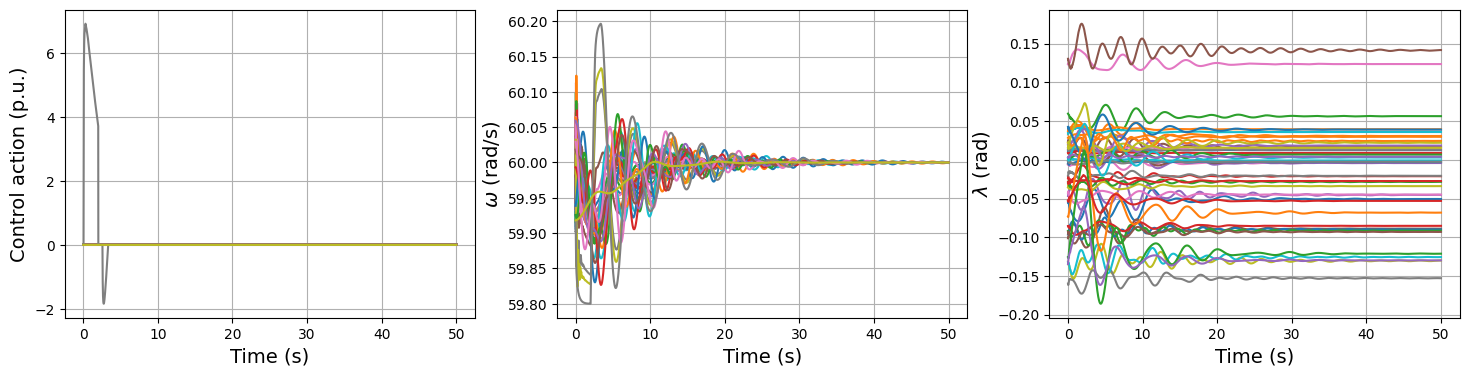

In [30]:
# Plot the trajectory to visulize the performance of control

Trajectory_Linear_omega=[]
Trajectory_Linear_omega_true=[]
Trajectory_Linear_lambda=[]

initial_state1=np.transpose(D@np.linalg.pinv(L)@(Power_initial*np.random.uniform(-0.1,0.1,(dim_omega,1))-syn_frequence*np.transpose(E)))
initial_state2=np.random.uniform(-0.1,0.1,(1,dim_omega))*1
s_concate=np.hstack((initial_state1,initial_state2)).astype(np.float32)

init_state=equilibrium_init + s_concate
#
s=init_state
s_record_all_omega = s@env.select_omega
s_record_all_omega_true = s_record_all_omega + 60*np.ones((1,dim_omega))
s_record_all_lambda = s@env.select_lambda
env.set_state(s)
Trajectory_Linear_omega.append(s_record_all_omega)
Trajectory_Linear_omega_true.append(s_record_all_omega_true)
Trajectory_Linear_lambda.append(s_record_all_lambda)
Test_time=50
SimulationLength=int(Test_time/delta_t)
Record_u_Linear=[]
Record_Loss_Linear=[]
Loss_Linear=0

generator_loss_node = 38
# generator_loss_node_1 = 38
# generator_loss_node_2 = 35
# generator_loss_node_3 = 33
# generator_loss_node_4 = 32

generator_loss_start_time = 0
generator_loss_period = 2
for i in range(SimulationLength):
    if i>=generator_loss_start_time/delta_t and i<=(generator_loss_start_time+generator_loss_period)/delta_t:
      Pm[0,generator_loss_node-1] = 0
      # Pm[0,generator_loss_node_1-1] = 0
      # Pm[0,generator_loss_node_2-1] = 0
      # Pm[0,generator_loss_node_3-1] = 0
      # Pm[0,generator_loss_node_4-1] = 0
    else:
      Pm[0,generator_loss_node-1] = Pm_nominal[0,generator_loss_node-1]
      # Pm[0,generator_loss_node_1-1] = Pm_nominal[0,generator_loss_node_1-1]
      # Pm[0,generator_loss_node_2-1] = Pm_nominal[0,generator_loss_node_2-1]
      # Pm[0,generator_loss_node_3-1] = Pm_nominal[0,generator_loss_node_3-1]
      # Pm[0,generator_loss_node_4-1] = Pm_nominal[0,generator_loss_node_4-1]
    u=Action_Yifu(s,env)
    next_s, r= env.step(u,Pm)
    Loss_Linear+=r
    s=next_s
    s_record_all_omega = s@env.select_omega
    s_record_all_omega_true = s_record_all_omega + 60*np.ones((1,dim_omega))
    s_record_all_lambda = s@env.select_lambda
    Trajectory_Linear_omega.append(s_record_all_omega)
    Trajectory_Linear_omega_true.append(s_record_all_omega_true)
    Trajectory_Linear_lambda.append(s_record_all_lambda)
    Record_u_Linear.append(u)
    Record_Loss_Linear.append(np.squeeze(r))

Trajectory_Linear_omega=np.squeeze(np.asarray(Trajectory_Linear_omega))
Trajectory_Linear_omega_true=np.squeeze(np.asarray(Trajectory_Linear_omega_true))
Trajectory_Linear_lambda=np.squeeze(np.asarray(Trajectory_Linear_lambda))
Record_u_Linear=np.squeeze(np.asarray(Record_u_Linear))

plt.figure(figsize=(18,4), dpi=100)
TimeRecord=np.arange(1,SimulationLength+1)
TimeRecord=env.delta_t*TimeRecord
plt.subplot(1,3,1)

plt.plot(TimeRecord,Record_u_Linear)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Control action (p.u.)', fontsize=14)


plt.subplot(1,3,2)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_Linear_omega_true)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('$\omega$ (rad/s)', fontsize=14)


plt.subplot(1,3,3)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_Linear_lambda)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('$\lambda$ (rad)', fontsize=14)
init_state

In [31]:
(np.sum(np.power(Record_u_Linear,2))+env.Penalty_action*np.sum(np.power(Trajectory_Linear_omega,2)))/(50/0.0008)

np.float64(226.29868340703683)

# RNN

In [32]:
# RNN Cell to integrate state transition dynamics
global count_num
count_num=0

class MinimalRNNCell(keras.layers.Layer):

    def __init__(self,units,action_units,internal_units,env,batchsize,**kwargs):
        self.units = units
        self.state_size = units
        self.action_units = action_units
        self.internal_units = internal_units
        self.batchsize=batchsize

        # 使用 CPU 創建常量
        with tf.device('/CPU:0'):
            self.state_transfer1=tf.constant(env.state_transfer1,dtype=tf.float32)
            self.state_transfer2=tf.constant(env.state_transfer2,dtype=tf.float32)
            self.state_transfer3=tf.constant(env.state_transfer3,dtype=tf.float32)
            self.select_add_omega=tf.constant(env.select_add_omega,dtype=tf.float32)
            self.select_omega=tf.constant(env.select_omega,dtype=tf.float32)
            self.select_lambda=tf.constant(env.select_lambda,dtype=tf.float32)
            self.weight_recover=tf.constant(
                tf.linalg.band_part(-tf.ones((internal_units,internal_units),dtype=tf.float32),0,1) +
                2*tf.eye(internal_units,dtype=tf.float32), dtype=tf.float32)
            self.bias_recover=tf.constant(
                tf.linalg.band_part(tf.ones((internal_units,internal_units),dtype=tf.float32),0,-1) -
                tf.eye(internal_units,dtype=tf.float32), dtype=tf.float32)
            self.ones_frequency=tf.ones((action_units,internal_units),dtype=tf.float32)

        super(MinimalRNNCell, self).__init__(**kwargs)

    def build(self, input_shape):
        #alpha_plus and alpha_minus
        self.w_plus_temp0= self.add_weight(
            shape=(self.action_units,self.internal_units),
            initializer='uniform',
            trainable=True,
            name='w_plus_temp')

        self.b_plus_temp0 = self.add_weight(
            shape=(self.action_units,self.internal_units),
            initializer=tf.keras.initializers.RandomUniform(minval=0, maxval=0.1),
            trainable=True,
            constraint=tf.keras.constraints.MaxNorm(0.2),
            name='b_plus_temp')

        self.w_minus_temp0= self.add_weight(
            shape=(self.action_units,self.internal_units),
            initializer='uniform',
            trainable=True,
            name='w_minus_temp')

        self.b_minus_temp0 = self.add_weight(
            shape=(self.action_units,self.internal_units),
            initializer=tf.keras.initializers.RandomUniform(minval=0, maxval=0.1),
            trainable=True,
            constraint=tf.keras.constraints.MaxNorm(0.2),
            name='b_minus_temp')

        #omega_threshold
        self.t_plus_temp= self.add_weight(
            shape=(self.action_units,),
            initializer=tf.keras.initializers.RandomUniform(minval=0, maxval=0),
            trainable=True,
            name='t_plus_temp')

        self.t_minus_temp= self.add_weight(
            shape=(self.action_units,),
            initializer=tf.keras.initializers.RandomUniform(minval=0, maxval=0),
            trainable=True,
            name='t_minus_temp')

        #budgets
        self.d_temp= self.add_weight(
            shape=(1,self.action_units),
            initializer=tf.keras.initializers.RandomUniform(minval=0, maxval=0),
            trainable=True,
            name='d_temp')

        #controls
        self.q_plus_temp0= self.add_weight(
            shape=(self.action_units,self.internal_units),
            initializer='uniform',
            trainable=True,
            name='q_plus_temp')

        self.c_plus_temp0 = self.add_weight(
            shape=(self.action_units,self.internal_units),
            initializer=tf.keras.initializers.RandomUniform(minval=-0.1, maxval=0.1),
            trainable=True,
            constraint=tf.keras.constraints.MaxNorm(0.2),
            name='c_plus_temp')

        self.q_minus_temp0= self.add_weight(
            shape=(self.action_units,self.internal_units),
            initializer='uniform',
            trainable=True,
            name='q_minus_temp')

        self.c_minus_temp0 = self.add_weight(
            shape=(self.action_units,self.internal_units),
            initializer=tf.keras.initializers.RandomUniform(minval=-0.1, maxval=0.1),
            trainable=True,
            constraint=tf.keras.constraints.MaxNorm(0.2),
            name='c_minus_temp')

        self.built = True

    def call(self, inputs, states):
        # stacked ReLU structure to represent control network
        global count_num
        if count_num < int(T/2):
          Pm[0,37] = 0
        else:
          Pm[0,37] = Pm_nominal[0,37]

        prev_output = states[0]
        w_plus_temp=tf.math.abs(self.w_plus_temp0)
        b_plus_temp=tf.math.abs(self.b_plus_temp0)
        w_minus_temp=tf.math.abs(self.w_minus_temp0)
        b_minus_temp=tf.math.abs(self.b_minus_temp0)
        w_plus=K.dot(-w_plus_temp,self.weight_recover)
        b_plus=K.dot(-b_plus_temp,self.bias_recover)
        w_minus=K.dot(-w_minus_temp,self.weight_recover)
        b_minus=K.dot(-b_minus_temp,self.bias_recover)

        d=K.dot(self.d_temp,tf.eye(self.action_units,dtype=tf.float32))

        q_plus=self.q_plus_temp0
        c_plus=-tf.math.abs(self.c_plus_temp0)
        q_minus=self.q_minus_temp0
        c_minus=-tf.math.abs(self.c_minus_temp0)

        omega_th_max=omega_max*K.sigmoid(self.t_plus_temp)
        omega_th_min=omega_min*K.sigmoid(self.t_minus_temp)

        treshold_min_square=tf.math.minimum(omega_th_max**(2),omega_th_min**(2))

        def getBinaryTensor(imgTensor,boundary=0):
          one = tf.ones_like(imgTensor, dtype=tf.float32)
          zero = tf.zeros_like(imgTensor)
          return tf.where(imgTensor > boundary, one, zero)

        states_controlled = K.dot(prev_output,self.select_omega)

        status=getBinaryTensor(states_controlled-omega_th_max)+getBinaryTensor(omega_th_min-states_controlled)
        status_new=tf.linalg.diag(status)
        A_tilde=status_new@A_nom@status_new
        Laplacian_tilde_diag=K.sum(A_tilde,axis=2)
        Laplacian_tilde=-A_tilde+tf.linalg.diag(Laplacian_tilde_diag)

        budgets_temp=d@Laplacian_tilde
        scale = tf.math.reduce_max(-budgets_temp/treshold_min_square, axis=2)

        def getBinaryScale(Tensor,boundary=1):
          one = tf.ones_like(Tensor, dtype=tf.float32)
          scale_factor = tf.ones_like(Tensor)
          return tf.where(Tensor > boundary, Tensor, one)

        scale_new = tf.linalg.diag(getBinaryScale(scale))@tf.ones((1,dim_omega))
        budgets=tf.squeeze(budgets_temp/scale_new)

        alpha_plus = K.sum(K.relu(-K.dot(tf.linalg.diag(states_controlled-env.omega_max*tf.ones((self.action_units,))),self.ones_frequency)+b_plus)*w_plus,axis=2)
        alpha_minus = K.sum(K.relu(-K.dot(tf.linalg.diag(env.omega_min*tf.ones((self.action_units,))-states_controlled),self.ones_frequency)+b_minus)*w_minus,axis=2)

        q_xp = env.E*states_controlled+(K.sin(K.dot(prev_output,self.select_lambda))@D_reactance)@D-np.squeeze(Pm)

        control_plus = K.sum(K.relu(K.dot(tf.linalg.diag(states_controlled-omega_th_max),self.ones_frequency)+c_plus)*q_plus,axis=2)
        control_minus = K.sum(K.relu(-K.dot(tf.linalg.diag(states_controlled-omega_th_min),self.ones_frequency)+c_minus)*q_minus,axis=2)

        nonlinear_plus = getBinaryTensor(states_controlled-omega_th_max, boundary=0)*\
                    tf.math.minimum(tf.math.minimum(states_controlled+budgets*((states_controlled+1e-8)**(-1)), control_plus+control_minus), -alpha_plus*((states_controlled-omega_th_max+1e-8)**(-1))+q_xp)
        nonlinear_minus = getBinaryTensor(omega_th_min-states_controlled, boundary=0)*\
                    tf.math.maximum(tf.math.maximum(states_controlled+budgets*((states_controlled+1e-8)**(-1)), control_plus+control_minus), alpha_minus*((omega_th_min-states_controlled+1e-8)**(-1))+q_xp)

        action = nonlinear_plus + nonlinear_minus

        # integrate the state transition dynamics
        new_state = prev_output@self.state_transfer1 \
                -((delta_t*((K.sin(K.dot(prev_output,self.select_lambda)))@D_reactance)@D)*(M**(-1)))@self.state_transfer2 \
                    + (np.ones((self.batchsize,1),dtype=np.float32)@Pm+action)@self.state_transfer3

        loss0 = K.dot(K.pow(new_state,2),self.select_add_omega)
        frequency=K.dot(new_state,self.select_omega)

        # 將多個輸出拼接成單一張量
        output_combined = tf.concat([
            loss0,
            frequency,
            action
        ], axis=1)

        count_num += 1
        if count_num == T - 1:
            print("One Episode Ended")
            count_num = 0

        return output_combined, [new_state]

In [ ]:
# 訓練模塊
start = time.time()

episodes = 100 # total number of iterations to update weights
action_units=dim_omega
units=dim_omega+dim_lambda #dimension of each state
internal_units=20 # demension of the neural network for control policy
T=5000  #Total period considered
Batch_num=50 # number of batch in each episodes 60

cell = MinimalRNNCell(units,action_units,internal_units,env,Batch_num)

# 關鍵修改：使用非 stateful RNN 並通過 initial_state 參數傳遞狀態
layer = RNN(cell, return_sequences=True, stateful=False)

# 模型定義 - 修改為接受初始狀態作為輸入
input_1 = tf.keras.Input(batch_shape=(Batch_num, T, units))
initial_state_input = tf.keras.Input(batch_shape=(Batch_num, units))

# 使用 initial_state 參數
outputs_combined = layer(input_1, initial_state=[initial_state_input])

# 拆分輸出
loss0 = outputs_combined[:, :, :1]  # 第一個維度是loss0
frequency = outputs_combined[:, :, 1:1+dim_omega]  # 接下來的dim_omega維是frequency
action = outputs_combined[:, :, 1+dim_omega:1+2*dim_omega]  # 最後的dim_omega維是action

# 修改模型以接受兩個輸入
model = tf.keras.models.Model([input_1, initial_state_input], [loss0, frequency, action])
model.compile(optimizer='Adam', loss='mse', metrics=['accuracy'])

x0=np.ones((Batch_num,T,units))

Loss_record=[]
Pe_rnn_record=[]
global_step = tf.Variable(0, trainable=False)
learning_rate_initial=0.2
optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate_initial)
PrintUpdate=1
delta_rnn_init_bound=0
omega_rnn_init_bound=0.1 #in Hz

for i in range(0,episodes):
    initial_state1=np.transpose(D@np.linalg.pinv(L)@(Power_initial*np.random.uniform(-0.1,0.1,(dim_omega,Batch_num))-syn_frequence*1*np.ones((dim_omega,Batch_num),dtype=np.float32)))
    initial_state2=np.random.uniform(-omega_rnn_init_bound,omega_rnn_init_bound,(Batch_num,action_units))
    initial_state=np.hstack((initial_state1,initial_state2)) + np.ones((Batch_num,1))@equilibrium_init

    # 關鍵修改：使用 initial_state 參數而不是手動設置狀態
    with tf.GradientTape(persistent=True) as tape:
        [loss0,frequency,action] = model([x0, initial_state], training=True)
        loss=0.1*(env.Penalty_action*K.sum(K.max(K.abs(frequency),axis=1))+K.sum(K.pow(action,2)))/(Batch_num*T)

    grads = tape.gradient(loss, model.variables)
    optimizer.apply_gradients(zip(grads, model.variables))
    Loss_record.append(loss)

    if i % (PrintUpdate) == 0:
        print('episode',i, 'Loss',loss)
        print('episode',i, 'Loss_frequency',(env.Penalty_action*K.sum(K.max(K.abs(frequency),axis=1)))/(Batch_num*T))
        print('episode',i, 'Loss_action',(K.sum(K.pow(action,2)))/(Batch_num*T))

end = time.time()
print(f"訓練時間: {end - start} 秒")

plt.plot(Loss_record)
plt.xlabel('episode')
plt.ylabel('Loss')
plt.grid()
plt.title('Accounted Training Loss')
file_name='loss_ours_saturation.mat'
savemat(file_name,{'Loss_record':Loss_record})

One Episode Ended
episode 0 Loss tf.Tensor(2.5650082, shape=(), dtype=float32)
episode 0 Loss_frequency tf.Tensor(5.142966, shape=(), dtype=float32)
episode 0 Loss_action tf.Tensor(20.507116, shape=(), dtype=float32)
One Episode Ended
episode 1 Loss tf.Tensor(2.2528052, shape=(), dtype=float32)
episode 1 Loss_frequency tf.Tensor(5.630725, shape=(), dtype=float32)
episode 1 Loss_action tf.Tensor(16.897327, shape=(), dtype=float32)
One Episode Ended
episode 2 Loss tf.Tensor(2.0675905, shape=(), dtype=float32)
episode 2 Loss_frequency tf.Tensor(5.790372, shape=(), dtype=float32)
episode 2 Loss_action tf.Tensor(14.885531, shape=(), dtype=float32)
One Episode Ended


In [ ]:
plt.plot(Loss_record)
plt.xlabel('episoid')
plt.ylabel('Loss')
plt.grid()
plt.title('Accounted Training Loss')
file_name='loss_ours_saturation.mat'
savemat(file_name,{'Loss_record':Loss_record})

# Simulate

In [ ]:
def Action(state,model,env):

    w_plus=K.dot(-tf.math.abs(model.variables[0]),cell.weight_recover).numpy()
    b_plus=K.dot(-tf.math.abs(model.variables[1]),cell.bias_recover).numpy()
    w_minus=K.dot(-tf.math.abs(model.variables[2]),cell.weight_recover).numpy()
    b_minus=K.dot(-tf.math.abs(model.variables[3]),cell.bias_recover).numpy()

    omega_th_max=omega_max*K.sigmoid(model.variables[4]).numpy()
    omega_th_min=omega_min*K.sigmoid(model.variables[5]).numpy()

    treshold_min_square=np.minimum(omega_th_max**(2),omega_th_min**(2))

    d=K.dot(model.variables[6],tf.eye(dim_omega,dtype=tf.float32))

    q_plus=(model.variables[7]).numpy()
    c_plus=(-tf.math.abs(model.variables[8])).numpy()
    q_minus=(model.variables[9]).numpy()
    c_minus=(-tf.math.abs(model.variables[10])).numpy()

    def getBinaryNumpy(imgNumpy, boundary = 0):
        one = np.ones_like(imgNumpy)
        zero = np.zeros_like(imgNumpy)
        return np.where(imgNumpy > boundary, one, zero)

    states_controlled = state@cell.select_omega

    status=getBinaryNumpy(states_controlled-omega_th_max)+getBinaryNumpy(omega_th_min-states_controlled)
    A_tilde=np.transpose(A_nom*np.squeeze(status))*np.squeeze(status)
    Laplacian_tilde_diag=np.sum(A_tilde,axis=0)
    Laplacian_tilde=-A_tilde+np.diag(Laplacian_tilde_diag)

    budgets_temp=d@Laplacian_tilde

    if np.max(-budgets_temp/treshold_min_square)<1:
      budgets=budgets_temp
    else:
      budgets=(budgets_temp/(np.max(-budgets_temp/(treshold_min_square))+1e-8))

    X_alpha_plus=-np.diag(np.squeeze(states_controlled-env.omega_max*np.ones((dim_omega,))))@cell.ones_frequency.numpy()+b_plus
    X_alpha_plus[X_alpha_plus<0]=0
    alpha_plus=np.sum(X_alpha_plus*w_plus,axis=1)
    X_alpha_minus=-np.diag(np.squeeze(env.omega_min*np.ones((cell.action_units,))-states_controlled))@cell.ones_frequency.numpy()+b_minus
    X_alpha_minus[X_alpha_minus<0]=0
    alpha_minus = np.sum(X_alpha_minus*w_minus,axis=1)

    q_xp = env.E*states_controlled+(np.sin(state@cell.select_lambda)@D_reactance)@D-np.squeeze(Pm)

    X_control_plus=np.diag(np.squeeze(states_controlled-omega_th_max))@cell.ones_frequency.numpy()+c_plus
    X_control_plus[X_control_plus<0]=0
    control_plus = np.sum(X_control_plus*q_plus,axis=1)
    X_control_minus=-np.diag(np.squeeze(states_controlled-omega_th_min))@cell.ones_frequency.numpy()+c_minus
    X_control_minus[X_control_minus<0]=0
    control_minus = K.sum(X_control_minus*q_minus,axis=1)
    control=control_plus+control_minus

    nonlinear_plus = getBinaryNumpy(states_controlled-omega_th_max, boundary=0)*\
                        np.minimum(np.minimum(states_controlled+budgets*((states_controlled+1e-8)**(-1)), -alpha_plus*((states_controlled-omega_th_max+1e-8)**(-1))+q_xp), control)
    nonlinear_minus = getBinaryNumpy(omega_th_min-states_controlled, boundary=0)*\
                        np.maximum(np.maximum(states_controlled+budgets*((states_controlled+1e-8)**(-1)), alpha_minus*((omega_th_min-states_controlled+1e-8)**(-1))+q_xp), control)
    #
    action = nonlinear_plus + nonlinear_minus

    # action = tf.math.minimum(tf.math.maximum(-3*tf.ones((1,dim_omega)),action),3*tf.ones((1,dim_omega))) ### projection

    return action


In [ ]:
# Compare the trajectory

Trajectory_RNN_omega=[]
Trajectory_RNN_omega_true=[]
Trajectory_RNN_lambda=[]

init_state=equilibrium_init + s_concate

# init_state=env.reset()
s=init_state
s_record_all_omega = s@env.select_omega
s_record_all_omega_true = s_record_all_omega + 60*np.ones((1,dim_omega))
s_record_all_lambda = s@env.select_lambda
env.set_state(s)
Trajectory_RNN_omega.append(s_record_all_omega)
Trajectory_RNN_omega_true.append(s_record_all_omega_true)
Trajectory_RNN_lambda.append(s_record_all_lambda)
Test_time=50
SimulationLength=int(Test_time/delta_t)
Record_u=[]
Record_Loss=[]
Loss_RNN=0
Loss_RNN_discounted=0

generator_loss_node = 38
generator_loss_start_time = 0
generator_loss_period = 2
for i in range(SimulationLength):
    if i>=generator_loss_start_time/delta_t and i<=(generator_loss_start_time+generator_loss_period)/delta_t:
      Pm[0,generator_loss_node-1] = 0
    else:
      Pm[0,generator_loss_node-1] = Pm_nominal[0,generator_loss_node-1]
    u=Action(s,layer,env)
    next_s, r= env.step(u,Pm)
    Loss_RNN_discounted+=r
    Loss_RNN+=r
    s=next_s
    s_record_all_omega = s@env.select_omega
    s_record_all_omega_true = s_record_all_omega + 60*np.ones((1,dim_omega))
    s_record_all_lambda = s@env.select_lambda
    Trajectory_RNN_omega.append(s_record_all_omega)
    Trajectory_RNN_omega_true.append(s_record_all_omega_true)
    Trajectory_RNN_lambda.append(s_record_all_lambda)
    Record_u.append(u)
    Record_Loss.append(np.squeeze(r))
Trajectory_RNN_omega=np.squeeze(np.asarray(Trajectory_RNN_omega))
Trajectory_RNN_omega_true=np.squeeze(np.asarray(Trajectory_RNN_omega_true))
Trajectory_RNN_lambda=np.squeeze(np.asarray(Trajectory_RNN_lambda))
Record_u=np.squeeze(np.asarray(Record_u))
plt.figure(figsize=(18, 4), dpi=100)
TimeRecord=np.arange(1,SimulationLength+1)
TimeRecord=env.delta_t*TimeRecord
plt.subplot(1,3,1)

plt.plot(TimeRecord,Record_u)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Control action (p.u.)', fontsize=14)
plt.grid()

plt.subplot(1,3,2)

TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_RNN_omega_true)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('$\omega$ (rad/s)', fontsize=14)
plt.grid()

plt.subplot(1,3,3)

TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_RNN_lambda)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('$\lambda$ (rad)', fontsize=14)
plt.grid()

In [ ]:
(np.sum(np.power(Record_u,2))+env.Penalty_action*np.sum(np.power(Trajectory_RNN_omega,2)))/(50/0.0008)

In [ ]:
from scipy.io import loadmat
from scipy.io import savemat

w_plus=K.dot(-tf.math.abs(model.variables[0]),cell.weight_recover).numpy()
b_plus=K.dot(-tf.math.abs(model.variables[1]),cell.bias_recover).numpy()
w_minus=K.dot(-tf.math.abs(model.variables[2]),cell.weight_recover).numpy()
b_minus=K.dot(-tf.math.abs(model.variables[3]),cell.bias_recover).numpy()

omega_th_max=(omega_max*K.sigmoid(model.variables[4])).numpy()
omega_th_min=(omega_min*K.sigmoid(model.variables[5])).numpy()

d=(K.dot(model.variables[6],tf.eye(dim_omega,dtype=tf.float32))).numpy()

q_plus=(model.variables[7]).numpy()
c_plus=(-tf.math.abs(model.variables[8])).numpy()
q_minus=(model.variables[9]).numpy()
c_minus=(-tf.math.abs(model.variables[10])).numpy()

file_name='optimal_controllers_budgets.mat'
savemat(file_name,{'w_plus':w_plus,'w_minus':w_minus,'b_plus':b_plus,'b_minus':b_minus,'omega_th_max':omega_th_max,'omega_th_min':omega_th_min,'q_plus':q_plus,'q_minus':q_minus,'c_plus':c_plus,'c_minus':c_minus,'d':d})